In [15]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

In [16]:
N = 4
wm = 0.642570281124498
wd = 0.642570281124498
tlist = np.linspace(0, 50, 100)
dlist = np.linspace(0.0, 4.0, 20)
alist = np.linspace(0.1, 4.0, 20)

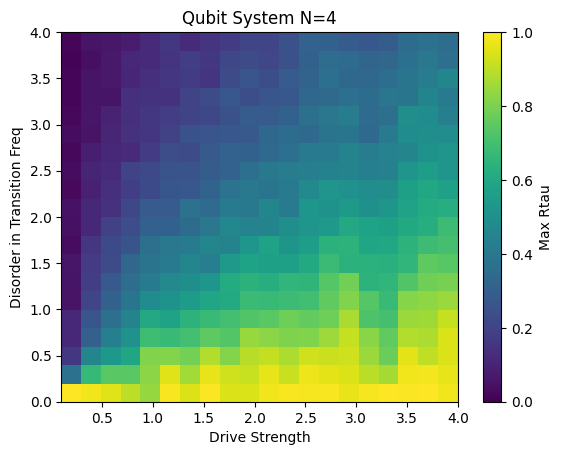

In [17]:
qdisRtau = []
for disorder in dlist:
    qampRtau = []
    for amp in alist:
        Rtau_qubit = []
        qargs = {"A": amp, "omega": wm}
        for _ in range(50):
            qH0, qH1 = get_qubit_ham(N, wm=wm, disorder=True, detuning=disorder, random_seed=True)
            qeigenvalues, qeigenstates = qH0.eigenstates()
            qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
            qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
            Rtau_qubit.append(np.array(np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / (qeigenvalues[-1] - qeigenvalues[0])))
        Rtau_qubit = np.array(Rtau_qubit)
        Rtau_qubit = np.mean(Rtau_qubit, axis=0)
        qampRtau.append(np.max(Rtau_qubit))
    qdisRtau.append(qampRtau)

plt.imshow(qdisRtau,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label="Max Rtau")
plt.title(f"Qubit System N={N}")
plt.ylabel(f"Disorder in Transition Freq")
plt.xlabel("Drive Strength")
plt.show()

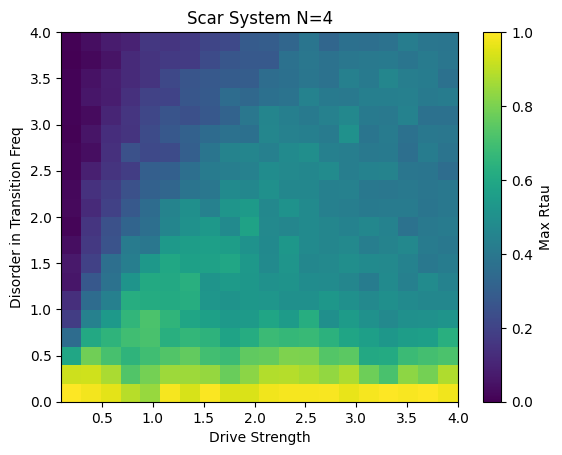

In [18]:
disRtau = []
for disorder in dlist:
    ampRtau = []
    for amp in alist:
        Rtau_scar = []
        args = {"A": amp, "omega": wd}
        for _ in range(50):
            H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, disorder=True, detuning=disorder, random_seed=True)
            H = qt.QobjEvo([H0, [H1, coeff]], args=args)
            psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
            Rtau_scar.append(np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0])))
        Rtau_scar = np.array(Rtau_scar)
        Rtau_scar = np.mean(Rtau_scar, axis=0)
        ampRtau.append(np.max(Rtau_scar))
    disRtau.append(ampRtau)

plt.imshow(disRtau,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label="Max Rtau")
plt.title(f"Scar System N={N}")
plt.ylabel("Disorder in Transition Freq")
plt.xlabel("Drive Strength")
plt.show()

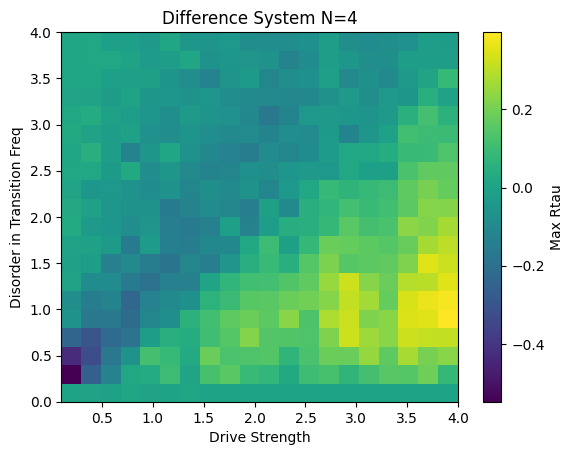

In [19]:
plt.imshow(np.array(qdisRtau) - np.array(disRtau),
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis') # , vmin=-0.3, vmax=0.3
plt.colorbar(label="Max Rtau")
plt.title(f"Difference System N={N}")
plt.ylabel("Disorder in Transition Freq")
plt.xlabel("Drive Strength")
plt.show()